# 그래프 설정

In [728]:
n = 4 #정점 수

In [897]:
edge = [
    (0, 1, 0),
    (0, 2, 0),
    (0, 3, 0),
    (1, 3, 0),
    (1, 2, 0),
]

# Plot Graph

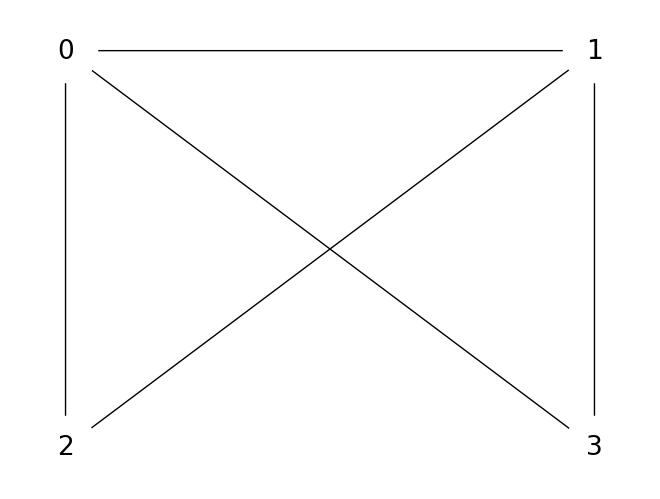

In [898]:
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph

pos = {
    0: (0, 1),
    1: (1, 1),
    2: (0, 0),
    3: (1, 0)
}

graph = rx.PyGraph()
graph.add_nodes_from(range(0, n))
graph.add_edges_from(edge)
draw_graph(graph, with_labels=True, pos=pos, node_size=2000, font_size=19, node_color="white")



# Hemiltonian

$$ H =-\sum_i{Z_i} + \mu_0 \sum_{(i, j)}{Z_iZ_j} $$

In [921]:
import numpy as np

In [922]:
from functools import reduce

# krons 함수 정의
def krons(*arr):
    return reduce(np.kron, arr)

Z = np.array([
    [1, 0],
    [0, -1]
])
I = np.identity(2)

com = rx.adjacency_matrix(graph).astype(int)
com

array([[0, 1, 1, 1],
       [1, 0, 1, 1],
       [1, 1, 0, 0],
       [1, 1, 0, 0]])

In [923]:
def zz(p1, p2):
    a = [I] * n
    a[p1] = Z
    a[p2] = Z
    return krons(*a)

def z(p1):
    a = [I] * n
    a[p1] = Z
    return krons(*a)

In [924]:
H = 0
H_I = np.eye(2**n)

for i in range(0, n):
    H -= H_I - z(i)

H /= 2

print(H)

[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -3.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. -2.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -2.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -3.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -2.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -3.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -3. 

In [925]:
mu = n + 1
for i in range(0, n):
    for j in range(i + 1, n):
        if com[i][j] == 0:
            H += zz(i, j) + H_I - z(i) - z(j)

H = mu * H / 4

print(H)


[[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.   -1.25  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.   -1.25  0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    2.5   0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.   -1.25  0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.   -2.5   0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.   -2.5   0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    1.25  0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.   -1.25  0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.   -2.5   0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0

<Axes: >

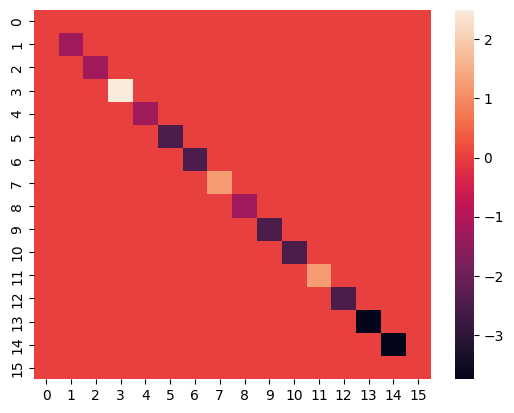

In [926]:
import seaborn as sns
sns.heatmap(H)

In [905]:
np.diag(H)

array([ 0.  , -1.25, -1.25,  2.5 , -1.25, -2.5 , -2.5 ,  1.25, -1.25,
       -2.5 , -2.5 ,  1.25, -2.5 , -3.75, -3.75,  0.  ])

In [906]:
from scipy.linalg import eig, eigvals
eigvals(H)

array([ 0.  +0.j, -1.25+0.j, -1.25+0.j,  2.5 +0.j, -1.25+0.j, -2.5 +0.j,
       -2.5 +0.j,  1.25+0.j, -1.25+0.j, -2.5 +0.j, -2.5 +0.j,  1.25+0.j,
       -2.5 +0.j, -3.75+0.j, -3.75+0.j,  0.  +0.j])

# Building QC

In [927]:
from qiskit.quantum_info import SparsePauliOp, Operator
H_q = SparsePauliOp.from_operator(H)
H_q

SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'ZIII'],
              coeffs=[-1.25 +0.j, -0.625+0.j, -0.625+0.j,  1.25 +0.j,  0.625+0.j,  0.625+0.j])

In [928]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
import numpy as np

In [929]:
def add(a, b):
    return a + b

def get_ansatz(qc, qubits, reps):

    unit_x = qubits
    unit_h2 = int(qubits*(qubits-1))

    theta_x =[[Parameter(f"theta_{i+unit_x*j}") for i in range(unit_x)] for j in range(reps)]
    phi_h =[[Parameter(f"phi_{i+unit_h2*j}") for i in range(unit_h2)] for j in range(reps)]

    indexes = list(range(qubits))
    for j in range(reps):
        theta_j = theta_x[j]
        for k in range(qubits):
            qc.rx(theta_j[k], k)
        phi_h_j = phi_h[j]
        for i, (a, b) in enumerate(combinations(indexes, 2)):
            qc.cx(a,b)
            qc.rz(phi_h_j[i], b)
            qc.rx(phi_h_j[i+int(unit_h2/2)], b)
            qc.cx(a,b)
        #qc.barrier(range(qubits))
    return reduce(add, theta_x) + reduce(add, phi_h)
# def get_ansatz(qc, qubits, reps):
#     theta = []
#     phi = []

#     for i in range(reps):
#         for j in range(qubits):
#             theta.append(Parameter(f'theta_{len(theta)}'))
#             theta.append(Parameter(f'theta_{len(theta)}'))
#             qc.rx(theta[-2], j)
#             qc.ry(theta[-1], j)
#         for s, e, _ in range(edge):
#             qc.cz(s, e)
#         for s, e, _ in range(edge):
#             phi.append(Parameter(f'phi_{len(phi)}'))
#             qc.rz(phi[-1], e)
#         for s, e, _ in range(edge):
#             qc.cz(s, e)
    
#     return (reduce(add, theta), reduce(add, phi))

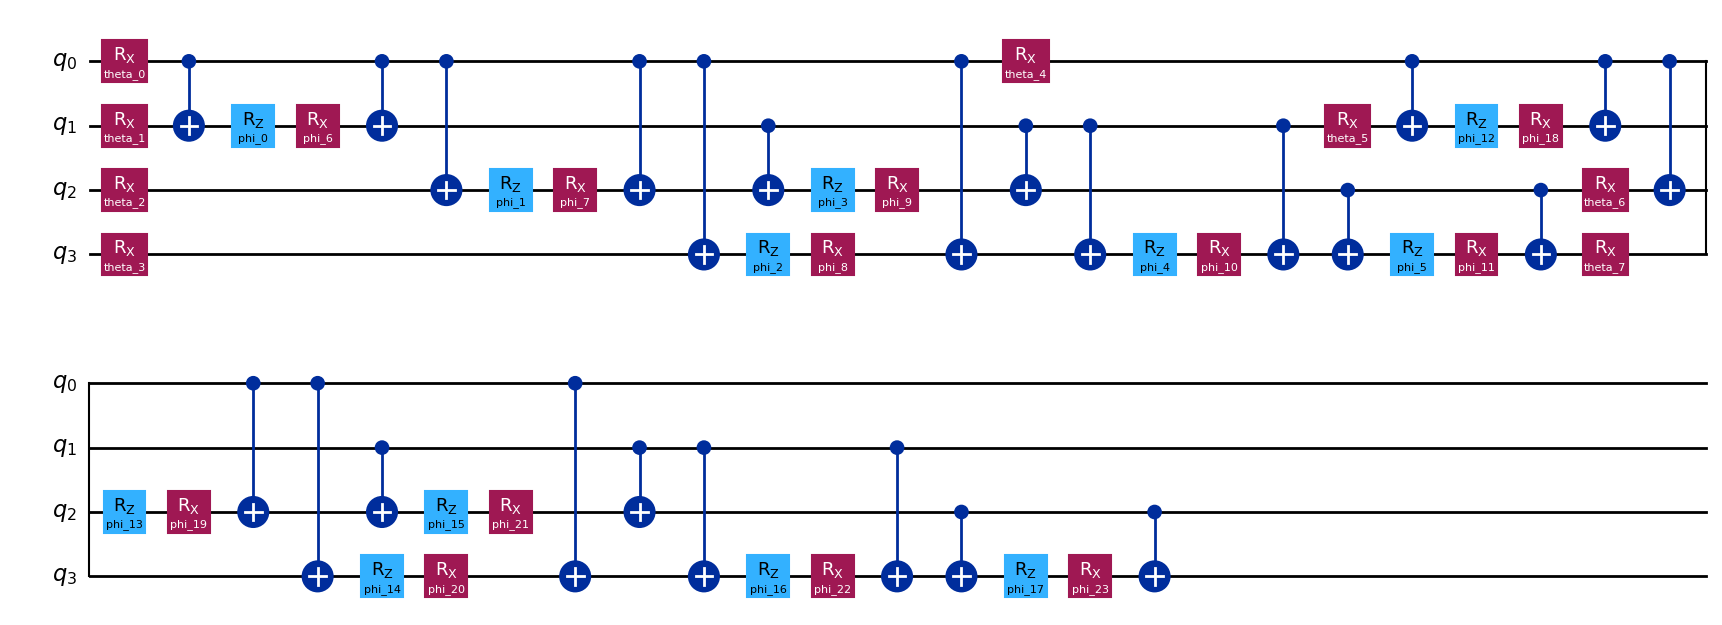

In [930]:

qubits = int(np.log2(H.shape[0]))
qc = QuantumCircuit(qubits) 
reps = 2
params = get_ansatz(qc, qubits, reps)
#EfficientSU2(qubits, reps=4, entanglement=[(edge[i][0], edge[i][1]) for i in range(len(edge))])
qc.draw('mpl')

In [931]:
print(params)

[Parameter(theta_0), Parameter(theta_1), Parameter(theta_2), Parameter(theta_3), Parameter(theta_4), Parameter(theta_5), Parameter(theta_6), Parameter(theta_7), Parameter(phi_0), Parameter(phi_1), Parameter(phi_2), Parameter(phi_3), Parameter(phi_4), Parameter(phi_5), Parameter(phi_6), Parameter(phi_7), Parameter(phi_8), Parameter(phi_9), Parameter(phi_10), Parameter(phi_11), Parameter(phi_12), Parameter(phi_13), Parameter(phi_14), Parameter(phi_15), Parameter(phi_16), Parameter(phi_17), Parameter(phi_18), Parameter(phi_19), Parameter(phi_20), Parameter(phi_21), Parameter(phi_22), Parameter(phi_23)]


In [932]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as Estimator
# SciPy minimizer routine
from scipy.optimize import minimize
from functools import reduce
def add(a,b):
    return a+b

estimator = Estimator()

#1 = len(params[0][0])
#l2 = len(params[1][0])
param_size = len(params)

x0 = np.pi/2 * np.random.random(param_size)
print(x0)
param = x0
pub = (qc.decompose(), [H_q], [param])

[0.25621621 0.98149306 0.80214481 0.31568554 1.08368937 1.4843581
 0.19015522 0.18737955 1.02250738 0.50798632 0.01923035 0.88063052
 0.07647552 0.84731358 1.42973936 1.4575782  0.65770771 0.72614678
 0.68151749 0.62537496 1.51116649 0.71396479 1.07229686 0.07636475
 0.19649587 0.6231499  0.90488088 0.39891715 0.51307124 1.1957831
 0.77978473 0.58082192]


In [933]:
result = estimator.run(pubs=[pub]).result()
energy = result[0].data.evs[0]
print(f"Initial energy: {energy}")

Initial energy: -1.4772941166600986


In [934]:
cost_history_dict = {
    "prev_vector": param,
    "iters": 0,
    "cost_history": [],
}

In [935]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    #print(params)
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy:.6}]")

    return energy

In [936]:
estimator = Estimator()
res = minimize(
    cost_func,
    cost_history_dict["prev_vector"],
    args = (qc.decompose(), H_q, estimator),
    method="cobyla"
)

Iters. done: 1 [Current cost: -1.47729]
Iters. done: 2 [Current cost: -1.31251]
Iters. done: 3 [Current cost: -1.76234]
Iters. done: 4 [Current cost: -1.70555]
Iters. done: 5 [Current cost: -1.86307]
Iters. done: 6 [Current cost: -1.8643]
Iters. done: 7 [Current cost: -1.51192]
Iters. done: 8 [Current cost: -1.66117]
Iters. done: 9 [Current cost: -2.18975]
Iters. done: 10 [Current cost: -2.57163]
Iters. done: 11 [Current cost: -2.59144]
Iters. done: 12 [Current cost: -2.07942]
Iters. done: 13 [Current cost: -2.6706]
Iters. done: 14 [Current cost: -2.71315]
Iters. done: 15 [Current cost: -2.43435]
Iters. done: 16 [Current cost: -2.72507]
Iters. done: 17 [Current cost: -2.73305]
Iters. done: 18 [Current cost: -2.72983]
Iters. done: 19 [Current cost: -1.9184]
Iters. done: 20 [Current cost: -2.04008]
Iters. done: 21 [Current cost: -2.42019]
Iters. done: 22 [Current cost: -2.47338]
Iters. done: 23 [Current cost: -2.49565]
Iters. done: 24 [Current cost: -2.9809]
Iters. done: 25 [Current cost

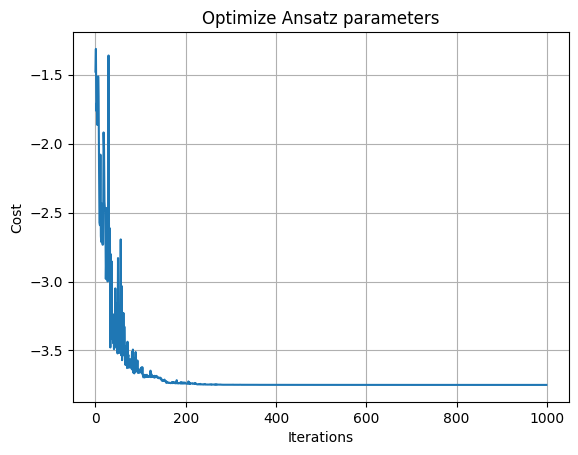

In [937]:
fig, ax = plt.subplots()
ax.plot(range(cost_history_dict["iters"]), cost_history_dict["cost_history"])
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost")
ax.grid()
ax.set_title("Optimize Ansatz parameters")
plt.draw()

In [938]:
pre_params = cost_history_dict["prev_vector"]
optim_gate = qc.to_gate()

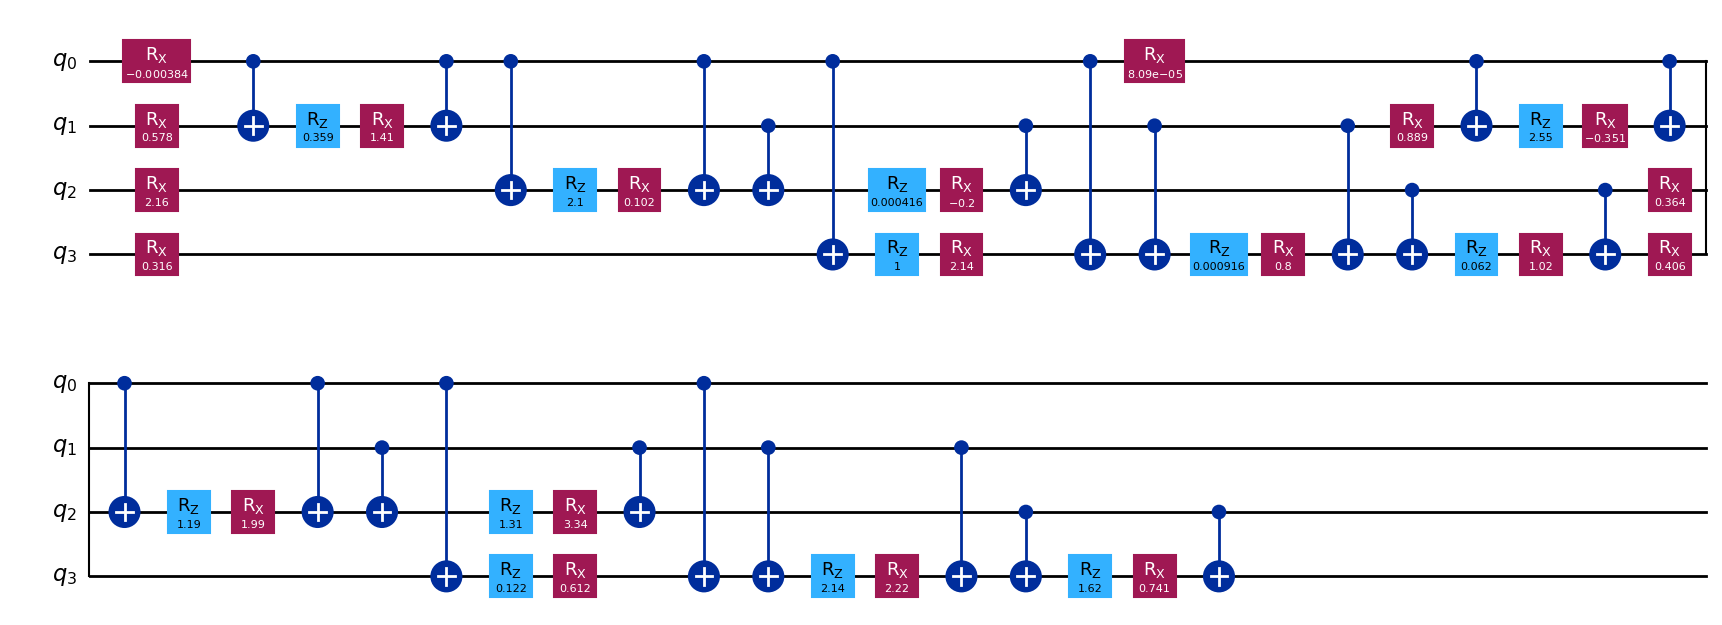

In [939]:
qc2 = QuantumCircuit(qubits )
qc2.append(
    qc.assign_parameters({angle: value  for angle, value in zip(list(qc.parameters), cost_history_dict["prev_vector"])}),
    range(qubits)
)
qc2.decompose().draw("mpl")

c:\Users\opoog\anaconda3\envs\urp\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\opoog\anaconda3\envs\urp\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


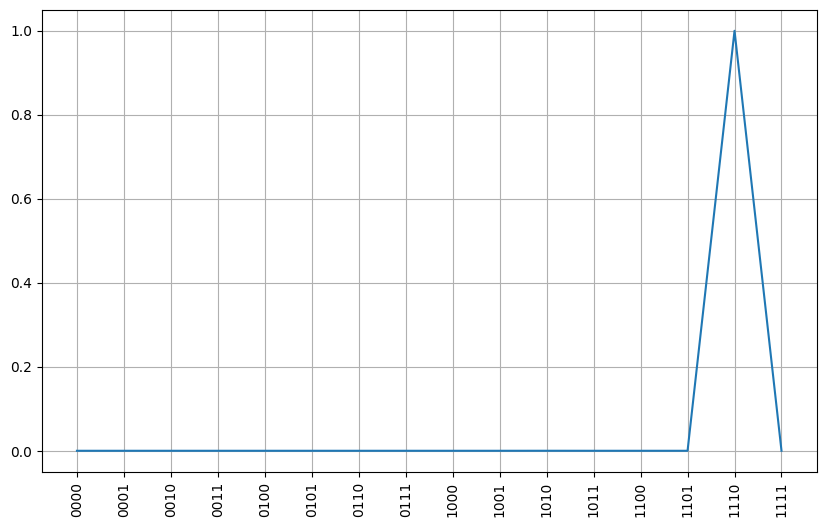

In [940]:
from qiskit_aer import Aer
from qiskit import QuantumCircuit, transpile
st_backend = Aer.get_backend("statevector_simulator")
circ = transpile(qc2, st_backend)
result = st_backend.run(circ).result()

state_vector =  result.data()['statevector']
st_np = state_vector.data

xdata = [format(i, f"0{qubits}b") for i in np.arange(2**qubits)]
ydata = st_np.conj()*st_np

plt.figure(figsize=(10, 6))
plt.plot(xdata, ydata)
plt.xticks(rotation=90)
plt.grid(True)
plt.show()